Wczytano:
- train: X=(2621, 40), y=(2621,)
- val:   X=(372, 40), y=(372,)
- test:  X=(872, 40), y=(872,)

Najlepsze k (na walidacji): 11 | val accuracy=0.9113
Top 10 k na walidacji:
  k=11  acc=0.9113
  k= 5  acc=0.8978
  k=13  acc=0.8978
  k=17  acc=0.8978
  k=15  acc=0.8952
  k=19  acc=0.8952
  k= 9  acc=0.8898
  k= 3  acc=0.8871
  k= 7  acc=0.8844
  k=25  acc=0.8817

=== MojKNN (test) ===
Accuracy: 0.8772935779816514
Confusion matrix:
 [[389  70]
 [ 37 376]]

=== sklearn KNeighborsClassifier (test) ===
Accuracy: 0.8772935779816514
Confusion matrix:
 [[389  70]
 [ 37 376]]

Classification report:
               precision    recall  f1-score   support

           0     0.9131    0.8475    0.8791       459
           1     0.8430    0.9104    0.8754       413

    accuracy                         0.8773       872
   macro avg     0.8781    0.8790    0.8773       872
weighted avg     0.8799    0.8773    0.8774       872


Zgodność Twojego MojKNN ze sklearn: 100.00%


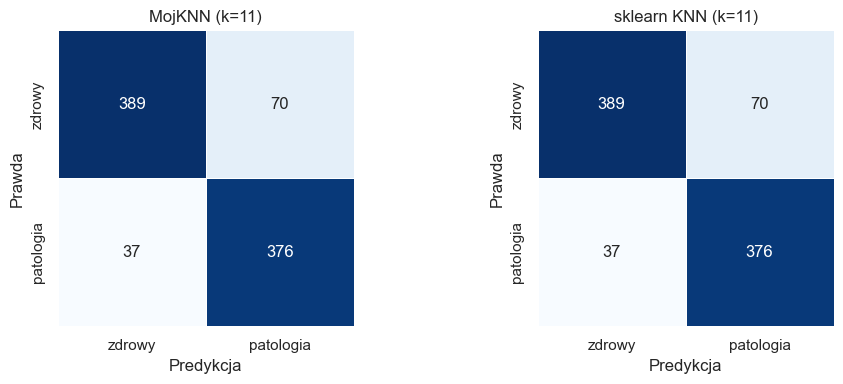

In [2]:
import numpy as np
import pandas as pd
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

sns.set_theme(style="whitegrid")

def odleglosc_euklidesowa(x1, x2):
    return np.sqrt(np.sum((x1 - x2) ** 2))


class MojKNN:
    def __init__(self, k=3):
        self.k = k

    def fit(self, X, y):
        self.X_train = np.asarray(X)
        self.y_train = np.asarray(y)

    def predict(self, X):
        X = np.asarray(X)
        przewidziane_klasy = [self._przewidz_pojedynczy(x) for x in X]
        return np.array(przewidziane_klasy)

    def _przewidz_pojedynczy(self, x):
        odleglosci = [odleglosc_euklidesowa(x, x_train) for x_train in self.X_train]
        k_indeksy = np.argsort(odleglosci)[: self.k]
        k_najblizsze_klasy = [self.y_train[i] for i in k_indeksy]
        najczestsza = Counter(k_najblizsze_klasy).most_common(1)
        return int(najczestsza[0][0])


def plot_cm_ax(cm, ax, labels=("zdrowy", "patologia"), title="Confusion matrix"):
    cm = np.asarray(cm)
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        square=True,
        linewidths=0.5,
        linecolor="white",
        xticklabels=labels,
        yticklabels=labels,
        ax=ax,
    )
    ax.set_xlabel("Predykcja")
    ax.set_ylabel("Prawda")
    ax.set_title(title)


def wczytaj_cechy_csv(sciezka_csv: str):
    """
    Wczytuje plik z cechami (np. features_test_segmented.csv).
    Oczekuje kolumny 'label' (0/1).
    Zwraca: X (numeryczne cechy), y (etykiety), df (całość).
    """
    df = pd.read_csv(sciezka_csv)
    if "label" not in df.columns:
        raise ValueError(f"Brak kolumny 'label' w pliku: {sciezka_csv}")

    y = df["label"].astype(int).to_numpy()

    # Zostawiamy tylko kolumny numeryczne (oprócz label)
    X_df = df.drop(columns=["label"], errors="ignore")
    X_df = X_df.select_dtypes(include=["number"])
    X = X_df.to_numpy(dtype=float)

    return X, y, df


# --- ŚCIEŻKI DO TWOICH DANYCH (segmented) ---
ROOT = Path(".").resolve()
TRAIN_CSV = ROOT / "features_train_segmented.csv"
VAL_CSV = ROOT / "features_val_segmented.csv"
TEST_CSV = ROOT / "features_test_segmented.csv"

for p in [TRAIN_CSV, VAL_CSV, TEST_CSV]:
    if not p.exists():
        raise FileNotFoundError(f"Nie znaleziono pliku: {p}")

X_train, y_train, df_train = wczytaj_cechy_csv(str(TRAIN_CSV))
X_val, y_val, df_val = wczytaj_cechy_csv(str(VAL_CSV))
X_test, y_test, df_test = wczytaj_cechy_csv(str(TEST_CSV))

print("Wczytano:")
print(f"- train: X={X_train.shape}, y={y_train.shape}")
print(f"- val:   X={X_val.shape}, y={y_val.shape}")
print(f"- test:  X={X_test.shape}, y={y_test.shape}")

# --- DOBÓR k NA WALIDACJI ---
# k-NN jest bardzo czuły na skalę cech -> standaryzacja (skalujemy na train, oceniamy na val)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s = scaler.transform(X_val)

# Szukamy po nieparzystych k (mniej remisów). Ograniczamy do liczby próbek w train.
max_k = min(51, len(y_train))
k_values = [k for k in range(1, max_k + 1, 2) if k >= 1]

wyniki = []
for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_s, y_train)
    pred_val = model.predict(X_val_s)
    acc_val = accuracy_score(y_val, pred_val)
    wyniki.append((k, acc_val))

# wybór najlepszego k: największa accuracy, a przy remisie mniejsze k
wyniki_sorted = sorted(wyniki, key=lambda t: (-t[1], t[0]))
BEST_K, BEST_VAL_ACC = wyniki_sorted[0]
print(f"\nNajlepsze k (na walidacji): {BEST_K} | val accuracy={BEST_VAL_ACC:.4f}")
print("Top 10 k na walidacji:")
for k, acc in wyniki_sorted[:10]:
    print(f"  k={k:2d}  acc={acc:.4f}")

#TESTUJEMY MODELE NA TEST 
# Uwaga: do finalnego testu trenujemy na (train+val), więc refitujemy scaler na (train+val).
X_trainval = np.vstack([X_train, X_val])
y_trainval = np.concatenate([y_train, y_val])

scaler_final = StandardScaler()
X_trainval_s = scaler_final.fit_transform(X_trainval)
X_test_s = scaler_final.transform(X_test)

RUN_CUSTOM = True  # ustaw na False, jeśli będzie za wolno
if RUN_CUSTOM:
    moj_model = MojKNN(k=BEST_K)
    moj_model.fit(X_trainval_s, y_trainval)
    moje_wyniki = moj_model.predict(X_test_s)
    cm_moj = confusion_matrix(y_test, moje_wyniki)
    print("\n=== MojKNN (test) ===")
    print("Accuracy:", accuracy_score(y_test, moje_wyniki))
    print("Confusion matrix:\n", cm_moj)

pro_model = KNeighborsClassifier(n_neighbors=BEST_K)
pro_model.fit(X_trainval_s, y_trainval)
pro_wyniki = pro_model.predict(X_test_s)
cm_sklearn = confusion_matrix(y_test, pro_wyniki)

print("\n=== sklearn KNeighborsClassifier (test) ===")
print("Accuracy:", accuracy_score(y_test, pro_wyniki))
print("Confusion matrix:\n", cm_sklearn)
print("\nClassification report:\n", classification_report(y_test, pro_wyniki, digits=4))

if RUN_CUSTOM:
    zgodnosc = np.mean(moje_wyniki == pro_wyniki) * 100
    print(f"\nZgodność Twojego MojKNN ze sklearn: {zgodnosc:.2f}%")

#CONFUSION MATRIX
labels = ["zdrowy", "patologia"]
if RUN_CUSTOM:
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    plot_cm_ax(cm_moj, axes[0], labels=labels, title=f"MojKNN (k={BEST_K})")
    plot_cm_ax(cm_sklearn, axes[1], labels=labels, title=f"sklearn KNN (k={BEST_K})")
else:
    fig, ax = plt.subplots(1, 1, figsize=(5, 4))
    plot_cm_ax(cm_sklearn, ax, labels=labels, title=f"sklearn KNN (k={BEST_K})")

plt.tight_layout()
plt.show()